In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)


In [3]:
DOMAIN_PATHS = {
    "kga": Path("/Projects/Bhavesh_project/embeddings/kga_dinov2l_embeddings_v2.h5"),
    "kru": Path("/Projects/Bhavesh_project/embeddings/kru_dinov2l_embeddings_v2.h5"),
    "kar": Path("/Projects/Bhavesh_project/embeddings/kar_dinov2l_embeddings_v2.h5"),
    "eno": Path("/Projects/Bhavesh_project/embeddings/eno_dinov2l_embeddings_v2.h5"),
}

TAXONOMY_MAPPING_PATH="/Projects/Bhavesh_project/cct_notebooks/json_files/lila-taxonomy-mapping.csv"
TAXONOMY_DOMAIN_KEYS = {'kga': "Snapshot Kgalagadi",
                       'kru': "Snapshot Kruger",
                       'kar': "Snapshot Karoo",
                       'eno': "Snapshot Enonkishu"}

TAXONOMY_DATASET_COLUMN = 'dataset_name'
TAXONOMY_LABEL_COLUMN = 'query'
TAXONOMY_TARGET_COLUMN = 'scientific_name'

N_BLOCKS = 4
INIT_TRAIN_RATIO = 0.6
OUTPUT_DIR = Path("outputs_notebook")

if len(DOMAIN_PATHS) != 4:
    raise ValueError("This notebook is configured for exactly 4 datasets.")
if not 0.0 < INIT_TRAIN_RATIO < 1.0:
    raise ValueError("INIT_TRAIN_RATIO must be strictly between 0 and 1.")

TRANSFER_PAIRS = [
    (source_name, target_name)
    for source_name in DOMAIN_PATHS
    for target_name in DOMAIN_PATHS
    if source_name != target_name
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

@dataclass(frozen=True)
class ExperimentConfig:
    domain_paths: Dict[str, Path]
    transfer_pairs: List[Tuple[str, str]]
    taxonomy_mapping_path: Path | None = None
    taxonomy_domain_keys: Dict[str, str] | None = None
    taxonomy_dataset_column: str | None = None
    taxonomy_label_column: str | None = None
    taxonomy_target_column: str | None = None
    n_blocks: int = 4
    init_train_ratio: float = 0.8
    output_dir: Path = Path("outputs_notebook")


@dataclass
class Dataset:
    embeddings: np.ndarray
    species: np.ndarray
    timestamps: np.ndarray
    dates: np.ndarray
    locations: np.ndarray


@dataclass
class DomainData:
    name: str
    dataset: Dataset
    blocks: List[np.ndarray]


@dataclass
class TaxonomyMapping:
    dataset_column: str
    label_column: str
    target_column: str
    label_map: Dict[Tuple[str, str], str]


config = ExperimentConfig(
    domain_paths=DOMAIN_PATHS,
    transfer_pairs=TRANSFER_PAIRS,
    taxonomy_mapping_path=TAXONOMY_MAPPING_PATH,
    taxonomy_domain_keys=TAXONOMY_DOMAIN_KEYS,
    taxonomy_dataset_column=TAXONOMY_DATASET_COLUMN,
    taxonomy_label_column=TAXONOMY_LABEL_COLUMN,
    taxonomy_target_column=TAXONOMY_TARGET_COLUMN,
    n_blocks=N_BLOCKS,
    init_train_ratio=INIT_TRAIN_RATIO,
    output_dir=OUTPUT_DIR,
)

print("Domains:", ", ".join(config.domain_paths.keys()))
print("Cross-domain pairs:", len(config.transfer_pairs))
print("Blocks per domain:", config.n_blocks)


Domains: kga, kru, kar, eno
Cross-domain pairs: 12
Blocks per domain: 4


In [4]:
def _decode_bytes(values: Sequence[object]) -> np.ndarray:
    return np.array(
        [v.decode() if isinstance(v, (bytes, np.bytes_)) else str(v) for v in values]
    )


def _norm_key(value: object) -> str:
    return str(value).strip().casefold()

def load_taxonomy_mapping(config: ExperimentConfig) -> TaxonomyMapping | None:
    if config.taxonomy_mapping_path is None:
        return None

    mapping_df = pd.read_csv(config.taxonomy_mapping_path)
    dataset_column = config.taxonomy_dataset_column or "dataset_name"
    label_column = config.taxonomy_label_column or "query"
    target_column = config.taxonomy_target_column or "scientific_name"

    required_columns = [dataset_column, label_column, target_column]
    missing_columns = [column for column in required_columns if column not in mapping_df.columns]
    if missing_columns:
        raise ValueError(
            f"Missing taxonomy mapping columns: {missing_columns}. "
            f"Available columns: {list(mapping_df.columns)}"
        )

    valid_rows = mapping_df[[dataset_column, label_column, target_column]].dropna(
        subset=[dataset_column, label_column, target_column]
    )

    label_map: Dict[Tuple[str, str], str] = {}
    for _, row in valid_rows.iterrows():
        target_value = str(row[target_column]).strip()
        if not target_value:
            continue
        key = (_norm_key(row[dataset_column]), _norm_key(row[label_column]))
        label_map[key] = target_value

    print("=" * 72)
    print("TAXONOMY MAPPING")
    print(f"  Path            : {config.taxonomy_mapping_path}")
    print(f"  Dataset column  : {dataset_column}")
    print(f"  Label column    : {label_column}")
    print(f"  Target column   : {target_column}")
    print(f"  Usable mappings : {len(label_map):,}")
    print("=" * 72)

    return TaxonomyMapping(
        dataset_column=dataset_column,
        label_column=label_column,
        target_column=target_column,
        label_map=label_map,
    )


def harmonize_species_labels(
    species: np.ndarray,
    domain_name: str,
    taxonomy_mapping: TaxonomyMapping | None,
    taxonomy_domain_keys: Dict[str, str] | None,
) -> np.ndarray:
    if taxonomy_mapping is None:
        return species

    dataset_key = (
        taxonomy_domain_keys.get(domain_name, domain_name)
        if taxonomy_domain_keys is not None
        else domain_name
    )
    dataset_norm = _norm_key(dataset_key)

    remapped = []
    n_mapped = 0
    unmapped_labels = set()
    for label in species:
        original_label = str(label)
        target_label = taxonomy_mapping.label_map.get(
            (dataset_norm, _norm_key(original_label))
        )
        if target_label is None:
            remapped.append(original_label)
            unmapped_labels.add(original_label)
        else:
            remapped.append(target_label)
            if target_label != original_label:
                n_mapped += 1

    remapped_arr = np.asarray(remapped)
    print(f"  Taxonomy key    : {dataset_key}")
    print(f"  Labels remapped : {n_mapped:,}")
    print(f"  Unique taxa     : {len(np.unique(remapped_arr))}")
    if unmapped_labels:
        preview = ", ".join(sorted(unmapped_labels)[:8])
        extra = "" if len(unmapped_labels) <= 8 else ", ..."
        print(
            f"  Unmapped labels : {len(unmapped_labels)} "
            f"(kept as original labels: {preview}{extra})"
        )

    return remapped_arr


def load_dataset(
    h5_path: Path,
    domain_name: str,
    taxonomy_mapping: TaxonomyMapping | None = None,
    taxonomy_domain_keys: Dict[str, str] | None = None,
) -> Dataset:
    with h5py.File(h5_path, "r") as hf:
        raw_embeddings = hf["embeddings"][:]
        raw_species = np.array(
            [
                s.decode() if isinstance(s, (bytes, np.bytes_)) else str(s)
                for s in hf["species"][:]
            ]
        )
        raw_strings = _decode_bytes(hf["date_captured"][:])
        if "location" in hf:
            raw_locations = _decode_bytes(hf["location"][:])
        else:
            raw_locations = np.full(len(raw_embeddings), "", dtype=object)

    temp_times = pd.to_datetime(raw_strings, errors="coerce")
    valid_timestamps = np.asarray(pd.notna(temp_times))
    finite_embeddings = np.isfinite(raw_embeddings).all(axis=1)
    nonzero_embeddings = np.linalg.norm(raw_embeddings, axis=1) > 0
    mask = valid_timestamps & finite_embeddings & nonzero_embeddings

    dropped = int((~mask).sum())
    if not np.any(mask):
        raise ValueError(
            f"Domain '{domain_name}' has no valid samples after cleaning timestamps and embeddings."
        )

    embeddings = normalize(raw_embeddings[mask], norm="l2")
    species = raw_species[mask]
    timestamps = np.asarray(temp_times)[mask]
    locations = raw_locations[mask]

    sort_idx = np.argsort(timestamps)
    embeddings = embeddings[sort_idx]
    species = species[sort_idx]
    timestamps = timestamps[sort_idx]
    locations = locations[sort_idx]
    dates = timestamps.astype("datetime64[D]")
    species = harmonize_species_labels(
        species, domain_name, taxonomy_mapping, taxonomy_domain_keys
    )

    print("=" * 72)
    print(f"DOMAIN: {domain_name}")
    print(f"  Path            : {h5_path}")
    print(f"  Samples loaded  : {len(embeddings):,}")
    print(f"  Samples dropped : {dropped:,}")
    print(f"  Time span       : {timestamps.min()} -> {timestamps.max()}")
    print(f"  Unique species  : {len(np.unique(species))}")

    return Dataset(
        embeddings=embeddings,
        species=species,
        timestamps=timestamps,
        dates=dates,
        locations=locations,
    )


def make_equal_time_blocks(dates: np.ndarray, n_blocks: int) -> List[np.ndarray]:
    if n_blocks < 1:
        raise ValueError("n_blocks must be at least 1.")
    if len(dates) == 0:
        raise ValueError("Cannot create blocks for an empty domain.")
    if len(dates) < n_blocks:
        raise ValueError(
            f"Cannot split {len(dates)} samples into {n_blocks} non-empty blocks."
        )

    date_days = dates.astype("datetime64[D]").astype(np.int64)
    unique_days = np.unique(date_days)
    if len(unique_days) < n_blocks:
        raise ValueError(
            f"Only {len(unique_days)} unique dates are available, fewer than {n_blocks} blocks."
        )

    start_day = int(unique_days[0])
    end_day = int(unique_days[-1])
    span_days = end_day - start_day + 1
    if span_days < n_blocks:
        raise ValueError(
            f"Time span covers only {span_days} calendar days, fewer than {n_blocks} blocks."
        )

    boundaries = np.floor(np.linspace(0, span_days, num=n_blocks + 1)).astype(int)
    if np.any(np.diff(boundaries) == 0):
        raise ValueError(
            f"Temporal boundaries collapsed for a {span_days}-day span and {n_blocks} blocks."
        )

    day_to_block: Dict[int, int] = {}
    for day in unique_days:
        offset = int(day - start_day)
        block_id = int(np.searchsorted(boundaries[1:], offset, side="right"))
        day_to_block[int(day)] = min(block_id, n_blocks - 1)

    blocks: List[List[int]] = [[] for _ in range(n_blocks)]
    for idx, day in enumerate(date_days):
        blocks[day_to_block[int(day)]].append(idx)

    result = [np.asarray(block, dtype=int) for block in blocks]
    empty_blocks = [i + 1 for i, block in enumerate(result) if len(block) == 0]
    if empty_blocks:
        raise ValueError(
            "Equal-time blocking produced empty blocks "
            f"{empty_blocks}. The domain likely has large temporal gaps."
        )

    return result


def print_blocks(label: str, blocks: Sequence[np.ndarray], dates: np.ndarray) -> None:
    print(f"\n{'-' * 60}")
    print(f"  {label} ({len(blocks)} blocks)")
    print(f"  {'Block':>6}  {'Size':>7}  {'Date range'}")
    print(f"  {'-' * 52}")
    for i, block in enumerate(blocks, start=1):
        d_min = dates[block].min()
        d_max = dates[block].max()
        print(f"  {i:>6}  {len(block):>7,}  {d_min} -> {d_max}")


def build_domain(
    name: str,
    h5_path: Path,
    n_blocks: int,
    taxonomy_mapping: TaxonomyMapping | None = None,
    taxonomy_domain_keys: Dict[str, str] | None = None,
) -> DomainData:
    dataset = load_dataset(h5_path, name, taxonomy_mapping, taxonomy_domain_keys)
    blocks = make_equal_time_blocks(dataset.dates, n_blocks)
    print_blocks(name, blocks, dataset.dates)

    total = sum(len(block) for block in blocks)
    if total != len(dataset.embeddings):
        raise ValueError(
            f"Domain '{name}' block sample mismatch: got {total:,}, expected {len(dataset.embeddings):,}."
        )
    print(f"  Total samples across blocks: {total:,}")
    print('\n\n\n')

    return DomainData(name=name, dataset=dataset, blocks=blocks)


In [18]:
class AdaptiveNCMClassifier:
    def __init__(self):
        self.prototypes = {}
        self.counts = {}

    def _normalized(self, v):
        n = np.linalg.norm(v)
        return v / n if n > 0 else v

    def _compute_dists(self, query_emb):
        if not self.prototypes:
            raise ValueError("Classifier has no prototypes. Fit the model first.")

        species_list = list(self.prototypes.keys())
        query_norm = self._normalized(query_emb)
        protos_norm = np.array(
            [self._normalized(self.prototypes[cls]) for cls in species_list]
        )

        dots = np.clip(protos_norm.dot(query_norm), -1.0, 1.0)
        dists = np.sqrt(np.maximum(0.0, 2.0 - 2.0 * dots))
        return species_list, dists

    def fit(self, g_embs, g_labels):
        for cls in np.unique(g_labels):
            cls_embs = g_embs[g_labels == cls]
            self.prototypes[cls] = np.mean(cls_embs, axis=0)
            self.counts[cls] = len(cls_embs)

    def update(self, new_emb, species):
        n = self.counts.get(species, 0)
        if n == 0:
            self.prototypes[species] = new_emb.copy()
            self.counts[species] = 1
            return

        old_proto = self.prototypes[species]
        new_n = n + 1
        self.prototypes[species] = (old_proto * n + new_emb) / new_n
        self.counts[species] = new_n

    def predict(self, query_emb):
        species_list, dists = self._compute_dists(query_emb)
        nearest_idx = int(np.argmin(dists))
        return species_list[nearest_idx]

    @property
    def known_species(self):
        return set(self.prototypes.keys())


def evaluate_block(clf, embs, lbls):
    species_in_block = sorted(set(lbls))

    sp_correct = {sp: 0 for sp in species_in_block}
    sp_total = {sp: 0 for sp in species_in_block}

    n_correct = 0

    for emb, lbl in zip(embs, lbls):
        pred = clf.predict(emb)
        sp_total[lbl] += 1
        if pred == lbl:
            n_correct += 1
            sp_correct[lbl] += 1

    total = len(lbls)

    per_species_accuracy = {
        sp: (100 * sp_correct[sp] / sp_total[sp] if sp_total[sp] > 0 else float("nan"))
        for sp in species_in_block
    }

    mean_species_accuracy = _nanmean(list(per_species_accuracy.values()))
    global_accuracy = 100 * n_correct / total if total > 0 else float("nan")

    return {
        "mean_species_accuracy": mean_species_accuracy,
        "global_accuracy": global_accuracy,
        "per_species_accuracy": per_species_accuracy,
        "n_correct_classifications": n_correct,
        "total": total,
    }


def _blk(domain: DomainData, indices: np.ndarray):
    return domain.dataset.embeddings[indices], domain.dataset.species[indices]


def _fmt(value: float) -> str:
    return f"{value:.2f}" if not np.isnan(value) else "n/a"


def _nanmean(values: Sequence[float]) -> float:
    arr = np.asarray(values, dtype=float)
    return float(np.nanmean(arr)) if not np.all(np.isnan(arr)) else float("nan")


def _get_internal_seed_clf(
    blocks,
    embeddings,
    species,
    init_train_ratio,
):
    block0_idx = np.asarray(blocks[0])
    n_block0 = len(block0_idx)

    n_fit = max(1, int(init_train_ratio * n_block0))
    n_fit = min(n_fit, n_block0)

    fit_idx = block0_idx[:n_fit]
    hold_idx = block0_idx[n_fit:]

    clf = AdaptiveNCMClassifier()
    clf.fit(embeddings[fit_idx], species[fit_idx])

    return clf, hold_idx


def _get_cross_domain_seed_clf(
    source_domain: DomainData,
    config: ExperimentConfig,
):
    clf = AdaptiveNCMClassifier()
    clf.fit(source_domain.dataset.embeddings, source_domain.dataset.species)
    return clf


def run_internal_pipeline(
    domain: DomainData,
    config: ExperimentConfig,
    update_model: bool = True,
):
    clf, hold_idx = _get_internal_seed_clf(
        domain.blocks,
        domain.dataset.embeddings,
        domain.dataset.species,
        config.init_train_ratio,
    )

    print("=" * 70)
    print(f"{domain.name} INTERNAL - {'ADAPTIVE' if update_model else 'STATIC'}")
    print("=" * 70)

    results = []

    hold_embs, hold_lbls = _blk(domain, hold_idx)
    n_before = len(clf.known_species)
    metrics = evaluate_block(clf, hold_embs, hold_lbls)

    if update_model:
        for emb, lbl in zip(hold_embs, hold_lbls):
            clf.update(emb, lbl)

    n_after = len(clf.known_species)
    results.append({
        "block": 1,
        **metrics,
        "n_known_before": n_before,
        "n_known_after": n_after,
    })

    print(
        f"  Block 1 | Mean species acc: {_fmt(metrics['mean_species_accuracy'])} | "
        f"Known: {n_before} -> {n_after}"
    )

    for i, block_idx in enumerate(domain.blocks[1:], start=2):
        block_embs, block_lbls = _blk(domain, block_idx)
        n_before = len(clf.known_species)

        metrics = evaluate_block(clf, block_embs, block_lbls)

        if update_model:
            for emb, lbl in zip(block_embs, block_lbls):
                clf.update(emb, lbl)

        n_after = len(clf.known_species)
        results.append({
            "block": i,
            **metrics,
            "n_known_before": n_before,
            "n_known_after": n_after,
        })

        print(
            f"  Block {i} | Mean species acc: {_fmt(metrics['mean_species_accuracy'])} | "
            f"Known: {n_before} -> {n_after}"
        )

    mean_accuracy = _nanmean(
        [result["mean_species_accuracy"] for result in results if result["block"] > 1]
    )
    print(f"  Mean block species accuracy (blocks 2..N): {_fmt(mean_accuracy)}")
    print("-" * 70)

    return results


def build_full_source_model(source_domain: DomainData, config: ExperimentConfig):
    clf = _get_cross_domain_seed_clf(source_domain, config)

    print(
        f"  Source seed model: {source_domain.name} | "
        f"Train samples: {sum(clf.counts.values()):,} | "
        f"Species: {len(clf.known_species):,}"
    )
    return clf


def run_cross_domain_pair(
    source_domain: DomainData,
    target_domain: DomainData,
    config: ExperimentConfig,
    update_model: bool = True,
):
    clf = build_full_source_model(source_domain, config)
    mode_name = "ADAPTIVE" if update_model else "STATIC"

    print("=" * 70)
    print(f"{source_domain.name} -> {target_domain.name} | {mode_name}")
    print("=" * 70)

    block_results = []
    for block_id, target_idx in enumerate(target_domain.blocks, start=1):
        target_embs, target_lbls = _blk(target_domain, target_idx)
        n_known_before = len(clf.known_species)

        metrics = evaluate_block(clf, target_embs, target_lbls)

        if update_model:
            for emb, lbl in zip(target_embs, target_lbls):
                clf.update(emb, lbl)

        n_known_after = len(clf.known_species)

        block_results.append({
            "target_block": block_id,
            **metrics,
            "n_known_before": n_known_before,
            "n_known_after": n_known_after,
            "n_source_samples": len(source_domain.dataset.embeddings),
            "n_source_species": len(np.unique(source_domain.dataset.species)),
        })

        print(
            f"  Target block {block_id} | "
            f"Mean species acc: {_fmt(metrics['mean_species_accuracy'])} | "
            f"Known: {n_known_before} -> {n_known_after}"
        )

    mean_accuracy = _nanmean(
        [
            result["mean_species_accuracy"]
            for result in block_results
            if result["target_block"] > 1
        ]
    )

    print(f"  Mean target-block species accuracy (blocks 2..N): {_fmt(mean_accuracy)}")
    print("-" * 70)

    return {
        "block_results": block_results,
        "mean_accuracy": mean_accuracy,
        "n_source_samples": len(source_domain.dataset.embeddings),
        "n_source_species": len(np.unique(source_domain.dataset.species)),
    }

In [22]:
def summarize_internal_results(
    internal_results: Dict[str, Dict[str, List[Dict[str, object]]]]
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rows: List[Dict[str, object]] = []

    for domain_name, variants in internal_results.items():
        for mode, results in variants.items():
            for result in results:
                rows.append(
                    {
                        "domain": domain_name,
                        "mode": mode,
                        "block": result["block"],
                        "mean_species_accuracy": result["mean_species_accuracy"],
                        "global_accuracy": result.get("global_accuracy", float("nan")),
                        "n_correct_classifications": result.get("n_correct_classifications", float("nan")),
                        "total": result["total"],
                        "n_known_before": result["n_known_before"],
                        "n_known_after": result["n_known_after"],
                    }
                )

    detail_df = pd.DataFrame(rows)
    mean_df = detail_df[detail_df["block"] > 1].copy()

    summary_df = (
        mean_df.groupby(["domain", "mode"], as_index=False)
        .agg(
            mean_species_accuracy=("mean_species_accuracy", lambda s: _nanmean(s.to_numpy(dtype=float))),
            mean_global_accuracy=("global_accuracy", lambda s: _nanmean(s.to_numpy(dtype=float))),
        )
    )

    return detail_df, summary_df


def summarize_cross_domain_results(
    cross_domain_results: Dict[Tuple[str, str], Dict[str, Dict[str, object]]]
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    block_rows: List[Dict[str, object]] = []
    summary_rows: List[Dict[str, object]] = []

    for (source_domain, target_domain), variants in cross_domain_results.items():
        for mode, result in variants.items():
            block_results = result["block_results"]
            eval_block_results = [br for br in block_results if br["target_block"] > 1]

            summary_rows.append(
                {
                    "source_domain": source_domain,
                    "target_domain": target_domain,
                    "mode": mode,
                    "mean_species_accuracy": _nanmean(
                        [br["mean_species_accuracy"] for br in eval_block_results]
                    ),
                    "mean_global_accuracy": _nanmean(
                        [br.get("global_accuracy", float("nan")) for br in eval_block_results]
                    ),
                    "n_source_samples": result["n_source_samples"],
                    "n_source_species": result["n_source_species"],
                }
            )

            for br in block_results:
                block_rows.append(
                    {
                        "source_domain": source_domain,
                        "target_domain": target_domain,
                        "mode": mode,
                        "target_block": br["target_block"],
                        "mean_species_accuracy": br["mean_species_accuracy"],
                        "global_accuracy": br.get("global_accuracy", float("nan")),
                        "n_correct_classifications": br.get("n_correct_classifications", float("nan")),
                        "total": br["total"],
                        "n_known_before": br["n_known_before"],
                        "n_known_after": br["n_known_after"],
                        "n_source_samples": br["n_source_samples"],
                        "n_source_species": br["n_source_species"],
                    }
                )

    return pd.DataFrame(block_rows), pd.DataFrame(summary_rows)


def build_gain_matrix(
    cross_summary_df: pd.DataFrame,
    domain_order: Sequence[str],
) -> pd.DataFrame:
    adaptive = (
        cross_summary_df[cross_summary_df["mode"] == "adaptive"]
        .pivot(index="source_domain", columns="target_domain", values="mean_species_accuracy")
        .reindex(index=domain_order, columns=domain_order)
    )
    static = (
        cross_summary_df[cross_summary_df["mode"] == "static"]
        .pivot(index="source_domain", columns="target_domain", values="mean_species_accuracy")
        .reindex(index=domain_order, columns=domain_order)
    )

    gain_matrix = adaptive - static
    for domain_name in domain_order:
        gain_matrix.loc[domain_name, domain_name] = np.nan

    return gain_matrix


def plot_internal_accuracy(
    internal_results: Dict[str, Dict[str, List[Dict[str, object]]]],
    output_dir: Path,
) -> None:
    plt.figure(figsize=(12, 7))
    cmap = plt.get_cmap("tab10")

    first_domain_results = next(iter(internal_results.values()))
    block_numbers = [r["block"] for r in first_domain_results["adaptive"]]

    for idx, (domain_name, variants) in enumerate(internal_results.items()):
        color = cmap(idx % 10)

        adaptive_vals = [r["mean_species_accuracy"] for r in variants["adaptive"]]
        static_vals = [r["mean_species_accuracy"] for r in variants["static"]]

        plt.plot(
            block_numbers,
            adaptive_vals,
            "o-",
            color=color,
            linewidth=2,
            label=f"{domain_name} (Adaptive)",
        )
        plt.plot(
            block_numbers,
            static_vals,
            "o--",
            color=color,
            linewidth=2,
            alpha=0.55,
            label=f"{domain_name} (Static)",
        )

    plt.title("Internal Temporal Mean Per-Species Accuracy Across Domains", fontsize=14)
    plt.xlabel("Timeline Blocks", fontsize=12)
    plt.ylabel("Mean Per-Species Accuracy (%)", fontsize=12)
    plt.ylim(0, 105)
    plt.xticks(block_numbers)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.legend(ncol=2, fontsize=9, frameon=True)
    plt.tight_layout()
    plt.savefig(output_dir / "internal_temporal_accuracy.pdf", dpi=200)
    plt.show()


def plot_cross_domain_gain_heatmap(gain_matrix: pd.DataFrame, output_dir: Path) -> None:
    plt.figure(figsize=(8, 6))
    mask = gain_matrix.isna()
    ax = sns.heatmap(
        gain_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        linewidths=0.5,
    )

    for i in range(min(gain_matrix.shape)):
        ax.add_patch(
            plt.Rectangle(
                (i, i),
                1,
                1,
                facecolor="#d9d9d9",
                edgecolor="white",
                linewidth=0.5,
                zorder=3,
            )
        )

    plt.xlabel("Evaluation dataset")
    plt.ylabel("Training dataset")
    plt.tight_layout()
    plt.savefig(output_dir / "cross_domain_gain_matrix.pdf", dpi=200, bbox_inches="tight")
    plt.close()


def export_results(
    internal_detail_df: pd.DataFrame,
    internal_summary_df: pd.DataFrame,
    cross_block_detail_df: pd.DataFrame,
    cross_summary_df: pd.DataFrame,
    gain_matrix: pd.DataFrame,
    output_dir: Path,
) -> None:
    internal_detail_df.to_csv(output_dir / "internal_results.csv", index=False)
    internal_summary_df.to_csv(output_dir / "internal_summary.csv", index=False)
    cross_block_detail_df.to_csv(output_dir / "cross_domain_block_results.csv", index=False)
    cross_summary_df.to_csv(output_dir / "cross_domain_summary.csv", index=False)
    gain_matrix.to_csv(output_dir / "cross_domain_gain_matrix.csv")

In [28]:
taxonomy_mapping = load_taxonomy_mapping(config)

domains = {
    name: build_domain(
        name,
        path,
        config.n_blocks,
        taxonomy_mapping,
        config.taxonomy_domain_keys,
    )
    for name, path in config.domain_paths.items()
}

internal_results: Dict[str, Dict[str, List[Dict[str, object]]]] = {}
for name, domain in domains.items():
    internal_results[name] = {
        "adaptive": run_internal_pipeline(domain, config, True),
        "static": run_internal_pipeline(domain, config, False),
    }

cross_domain_results: Dict[Tuple[str, str], Dict[str, Dict[str, object]]] = {}
for source_name, target_name in config.transfer_pairs:
    cross_domain_results[(source_name, target_name)] = {
        "adaptive": run_cross_domain_pair(domains[source_name], domains[target_name], config, True),
        "static": run_cross_domain_pair(domains[source_name], domains[target_name], config, False),
    }


TAXONOMY MAPPING
  Path            : /Projects/Bhavesh_project/cct_notebooks/json_files/lila-taxonomy-mapping.csv
  Dataset column  : dataset_name
  Label column    : query
  Target column   : scientific_name
  Usable mappings : 2,251
  Taxonomy key    : Snapshot Kgalagadi
  Labels remapped : 2,188
  Unique taxa     : 28
DOMAIN: kga
  Path            : /Projects/Bhavesh_project/embeddings/kga_dinov2l_embeddings_v2.h5
  Samples loaded  : 2,188
  Samples dropped : 0
  Time span       : 2018-10-27T20:00:26.000000000 -> 2019-01-13T03:36:06.000000000
  Unique species  : 28

------------------------------------------------------------
  kga (4 blocks)
   Block     Size  Date range
  ----------------------------------------------------
       1      239  2018-10-27 -> 2018-11-14
       2      375  2018-11-17 -> 2018-12-04
       3      834  2018-12-05 -> 2018-12-24
       4      740  2018-12-25 -> 2019-01-13
  Total samples across blocks: 2,188




  Taxonomy key    : Snapshot Kruger
  Labels

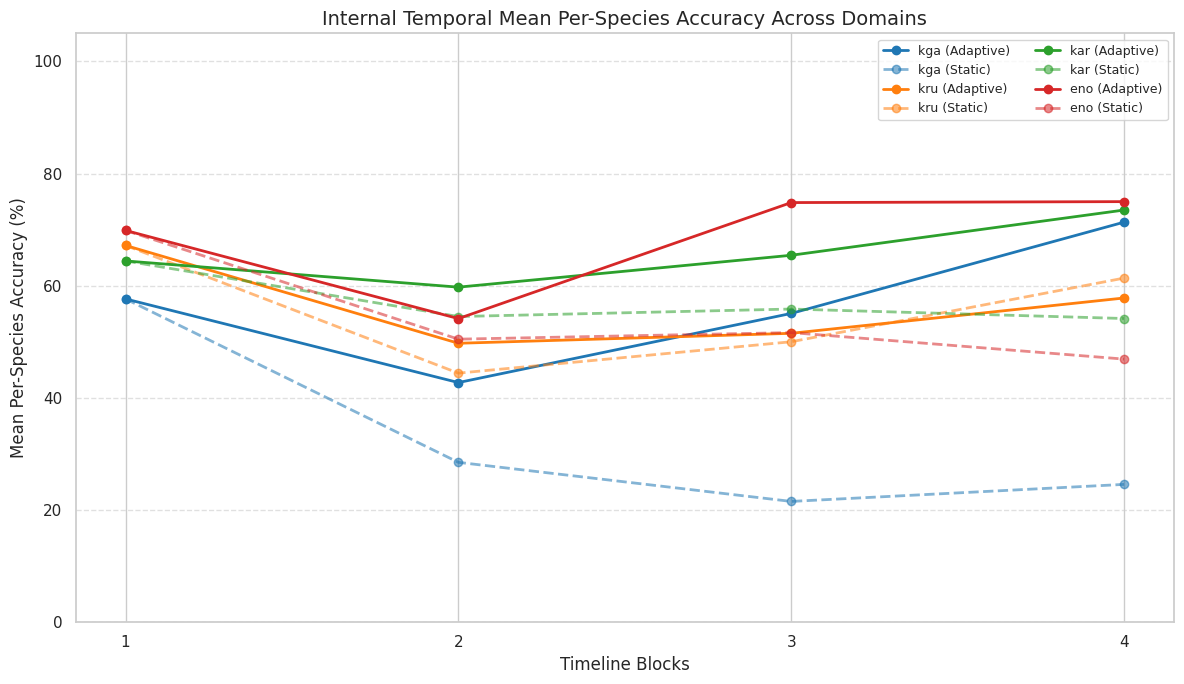

Saved outputs to: /Projects/Bhavesh_project/cct_notebooks/outputs_notebook

Internal mean per-species accuracies


,domain,mode,mean_species_accuracy,mean_global_accuracy
0,eno,adaptive,67.986965,89.538617
1,eno,static,49.678460,87.197715
2,kar,adaptive,66.223814,82.759583
3,kar,static,54.835454,82.427635
4,kga,adaptive,56.377020,83.893197
5,kga,static,24.877654,76.932184
6,kru,adaptive,53.023333,78.319983
7,kru,static,51.929565,77.849104



Cross-domain mean per-species accuracies


,source_domain,target_domain,mode,mean_species_accuracy,mean_global_accuracy,n_source_samples,n_source_species
0,eno,kar,adaptive,61.466855,77.842525,8407,34
1,eno,kar,static,19.400321,19.798587,8407,34
2,eno,kga,adaptive,57.806363,84.135671,8407,34
3,eno,kga,static,16.937472,6.672798,8407,34
4,eno,kru,adaptive,51.982467,75.451244,8407,34
5,eno,kru,static,39.675805,67.663214,8407,34
6,kar,eno,adaptive,68.063642,87.655520,5986,34
7,kar,eno,static,15.216434,17.585771,5986,34
8,kar,kga,adaptive,71.405997,87.224072,5986,34
9,kar,kga,static,61.369370,85.099298,5986,34



Adaptive gain matrix (mean per-species accuracy)


target_domain,kga,kru,kar,eno
source_domain,,,,
kga,,36.073,28.758,47.694
kru,35.651,,39.092,31.022
kar,10.037,31.613,,52.847
eno,40.869,12.307,42.067,


In [29]:
config.output_dir.mkdir(parents=True, exist_ok=True)

internal_detail_df, internal_summary_df = summarize_internal_results(internal_results)
cross_block_detail_df, cross_summary_df = summarize_cross_domain_results(cross_domain_results)
gain_matrix = build_gain_matrix(cross_summary_df, list(config.domain_paths.keys()))

plot_internal_accuracy(internal_results, config.output_dir)
plot_cross_domain_gain_heatmap(gain_matrix, config.output_dir)

export_results(
    internal_detail_df,
    internal_summary_df,
    cross_block_detail_df,
    cross_summary_df,
    gain_matrix,
    config.output_dir,
)

print(f"Saved outputs to: {config.output_dir.resolve()}")

print("\nInternal mean per-species accuracies")
display(internal_summary_df.sort_values(["domain", "mode"]).reset_index(drop=True))

print("\nCross-domain mean per-species accuracies")
display(
    cross_summary_df.sort_values(["source_domain", "target_domain", "mode"]).reset_index(drop=True)
)

print("\nAdaptive gain matrix (mean per-species accuracy)")
display(gain_matrix.style.format("{:.3f}", na_rep=""))

In [30]:
def build_global_domain(
    domains: Dict[str, DomainData],
    source_names: Sequence[str],
    n_blocks: int,
    global_name: str | None = None,
) -> DomainData:
    missing = [name for name in source_names if name not in domains]
    if missing:
        raise ValueError(f"Unknown source domains: {missing}")
    if len(source_names) < 2:
        raise ValueError("Global source must contain at least two domains.")

    source_embeddings = []
    source_species = []
    source_timestamps = []
    source_locations = []

    for name in source_names:
        ds = domains[name].dataset
        source_embeddings.append(ds.embeddings)
        source_species.append(ds.species)
        source_timestamps.append(ds.timestamps)
        source_locations.append(ds.locations)

    embeddings = np.concatenate(source_embeddings, axis=0)
    species = np.concatenate(source_species, axis=0)
    timestamps = pd.to_datetime(np.concatenate(source_timestamps)).to_numpy()
    locations = np.concatenate(source_locations, axis=0)

    sort_idx = np.argsort(timestamps)
    embeddings = embeddings[sort_idx]
    species = species[sort_idx]
    timestamps = timestamps[sort_idx]
    locations = locations[sort_idx]
    dates = timestamps.astype("datetime64[D]")

    dataset = Dataset(
        embeddings=embeddings,
        species=species,
        timestamps=timestamps,
        dates=dates,
        locations=locations,
    )

    blocks = make_equal_time_blocks(dataset.dates, n_blocks)

    name = global_name or f"GLOBAL[{'+'.join(source_names)}]"

    print("=" * 72)
    print(f"GLOBAL DOMAIN: {name}")
    print(f"  Source domains  : {', '.join(source_names)}")
    print(f"  Samples loaded  : {len(dataset.embeddings):,}")
    print(f"  Unique species  : {len(np.unique(dataset.species))}")
    print(f"  Time span       : {dataset.timestamps.min()} -> {dataset.timestamps.max()}")
    print_blocks(name, blocks, dataset.dates)

    return DomainData(name=name, dataset=dataset, blocks=blocks)

In [31]:
def run_global_cross_domain_experiment(
    domains: Dict[str, DomainData],
    source_names: Sequence[str],
    target_name: str,
    config: ExperimentConfig,
) -> Tuple[DomainData, Dict[str, Dict[str, object]]]:
    global_source = build_global_domain(
        domains=domains,
        source_names=source_names,
        n_blocks=config.n_blocks,
        global_name=f"GLOBAL[{'+'.join(source_names)}]",
    )

    target_domain = domains[target_name]

    results = {
        "adaptive": run_cross_domain_pair(global_source, target_domain, config, True),
        "static": run_cross_domain_pair(global_source, target_domain, config, False),
    }

    return global_source, results

In [32]:
def run_leave_one_out_global_snapshot_experiments(
    domains: Dict[str, DomainData],
    snapshot_names: Sequence[str],
    config: ExperimentConfig,
) -> Tuple[Dict[str, DomainData], Dict[Tuple[str, str], Dict[str, Dict[str, object]]]]:
    global_sources: Dict[str, DomainData] = {}
    global_results: Dict[Tuple[str, str], Dict[str, Dict[str, object]]] = {}

    for target_name in snapshot_names:
        source_names = [name for name in snapshot_names if name != target_name]

        global_source, results = run_global_cross_domain_experiment(
            domains=domains,
            source_names=source_names,
            target_name=target_name,
            config=config,
        )

        global_sources[target_name] = global_source
        global_results[(global_source.name, target_name)] = results

    return global_sources, global_results

In [33]:
snapshot_names = ["kar", "kru", "kga", "eno"]

global_sources, global_cross_domain_results = run_leave_one_out_global_snapshot_experiments(
    domains=domains,
    snapshot_names=snapshot_names,
    config=config,
)

global_block_detail_df, global_summary_df = summarize_cross_domain_results(
    global_cross_domain_results
)

print("\nAll global-source leave-one-out results")
display(
    global_summary_df.sort_values(["target_domain", "mode"]).reset_index(drop=True)
)

GLOBAL DOMAIN: GLOBAL[kru+kga+eno]
  Source domains  : kru, kga, eno
  Samples loaded  : 13,808
  Unique species  : 67
  Time span       : 2018-05-30T14:24:28.000000000 -> 2019-01-13T03:36:06.000000000

------------------------------------------------------------
  GLOBAL[kru+kga+eno] (4 blocks)
   Block     Size  Date range
  ----------------------------------------------------
       1    3,213  2018-05-30 -> 2018-07-16
       2       48  2018-09-04 -> 2018-09-20
       3    5,861  2018-09-21 -> 2018-11-16
       4    4,686  2018-11-17 -> 2019-01-13
  Source seed model: GLOBAL[kru+kga+eno] | Train samples: 13,808 | Species: 67
GLOBAL[kru+kga+eno] -> kar | ADAPTIVE
  Target block 1 | Acc: 42.93 | Known: 67 -> 71
  Target block 2 | Acc: 49.40 | Known: 71 -> 76
  Target block 3 | Acc: 59.89 | Known: 76 -> 76
  Target block 4 | Acc: 60.52 | Known: 76 -> 77
  Mean target-block accuracy: 53.19
----------------------------------------------------------------------
  Source seed model: GLOBA

,source_domain,target_domain,mode,mean_species_accuracy,mean_global_accuracy,n_source_samples,n_source_species
0,GLOBAL[kar+kru+kga],eno,adaptive,70.105939,87.309500,11387,67
1,GLOBAL[kar+kru+kga],eno,static,46.999812,60.025576,11387,67
2,GLOBAL[kru+kga+eno],kar,adaptive,56.603003,75.694650,13808,67
3,GLOBAL[kru+kga+eno],kar,static,43.660931,62.991859,13808,67
4,GLOBAL[kar+kru+eno],kga,adaptive,69.881355,86.826146,17606,72
5,GLOBAL[kar+kru+eno],kga,static,56.385515,84.921801,17606,72
6,GLOBAL[kar+kga+eno],kru,adaptive,52.084056,73.035318,16581,64
7,GLOBAL[kar+kga+eno],kru,static,48.388548,70.398578,16581,64
